In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt

In [3]:
fb1 = pd.read_csv('index_1.csv', sep=",")

In [6]:
fb1.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [7]:
#преобразуем столбец datetime в формат даты/времени.
#создаём новый столбец date  в формат даты/времени.
df = pd.read_csv('index_1.csv', parse_dates=['datetime'])
df['date'] = pd.to_datetime(df['date'])

In [8]:
#группируем все строки таблицы по дате и суммируем выручку за каждый день.
#сортируем Series по индексу (то есть по датам) в хронологическом порядке.
daily_revenue = df.groupby('date')['money'].sum()
daily_revenue = daily_revenue.sort_index()

In [9]:
daily_revenue.head()

date
2024-03-01    396.3
2024-03-02    228.1
2024-03-03    349.1
2024-03-04    135.2
2024-03-05    338.5
Name: money, dtype: float64

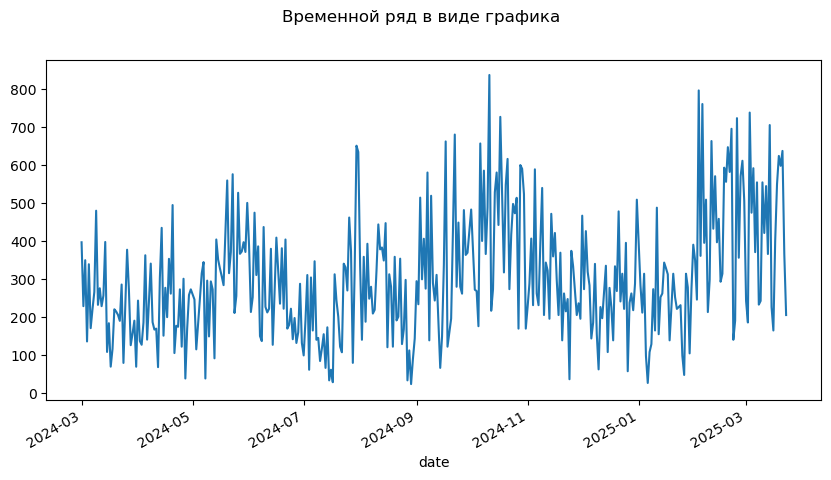

In [10]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд в виде графика')
daily_revenue.plot(ax=ax, legend=False)
pyplot.show()

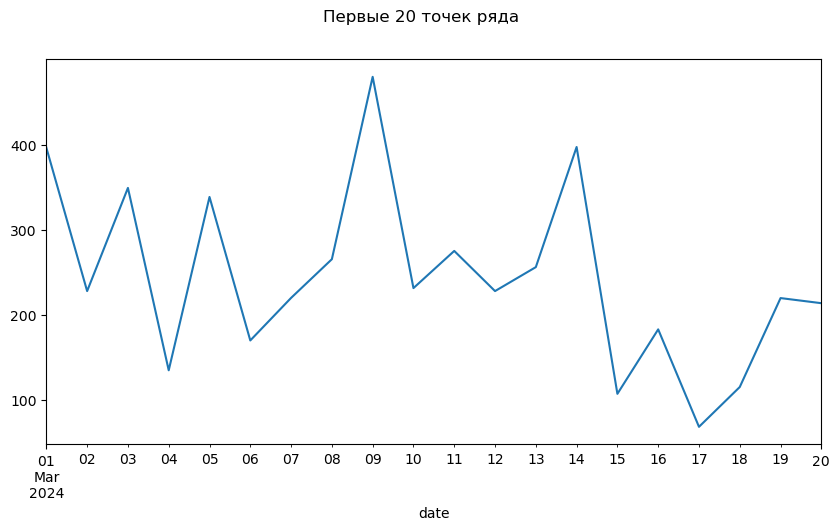

In [11]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Первые 20 точек ряда')
daily_revenue[:20].plot(ax=ax, legend=False)
pyplot.show()

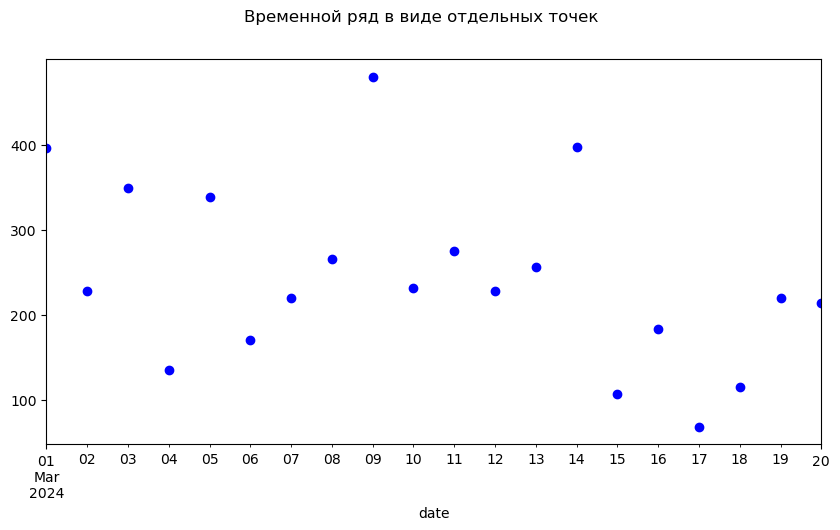

In [12]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд в виде отдельных точек')
daily_revenue[:20].plot(ax=ax, legend=False, style='bo')
pyplot.show()

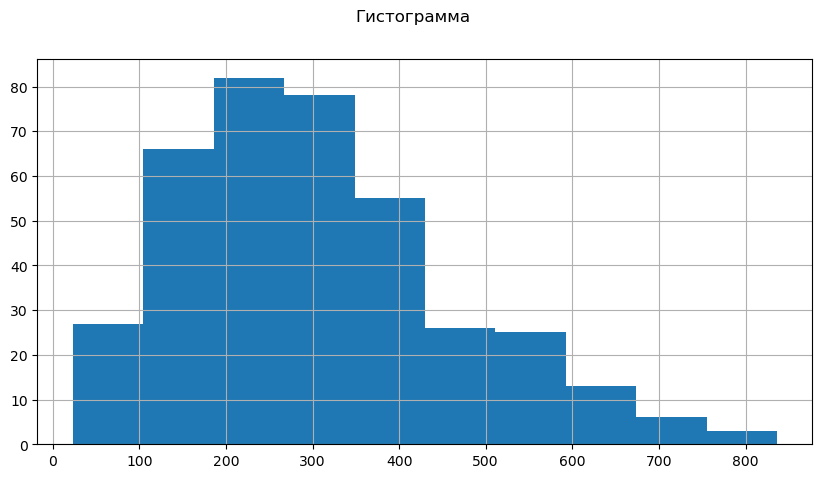

In [13]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Гистограмма')
daily_revenue.hist(ax=ax, legend=False)
pyplot.show()

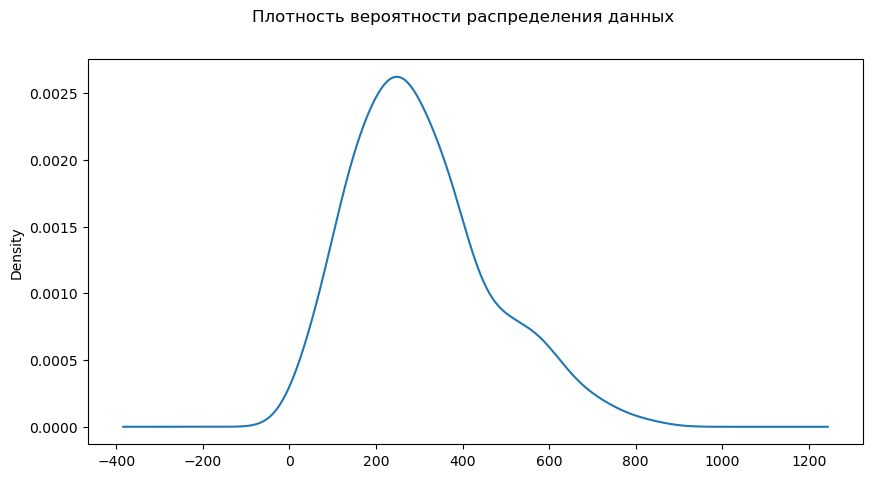

In [14]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Плотность вероятности распределения данных')
daily_revenue.plot(ax=ax, kind='kde', legend=False)
pyplot.show()

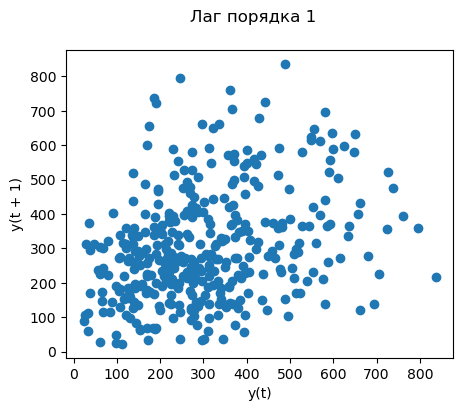

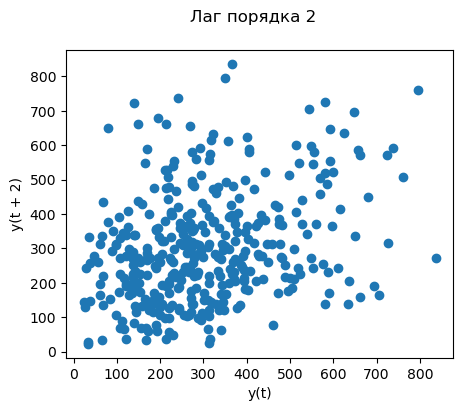

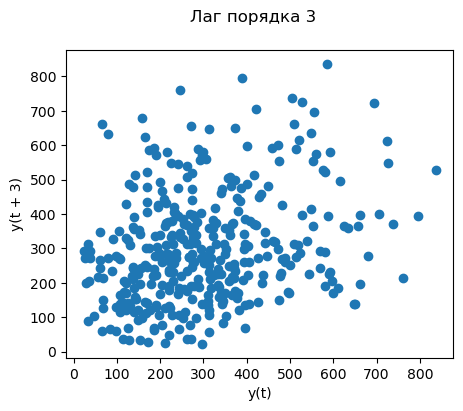

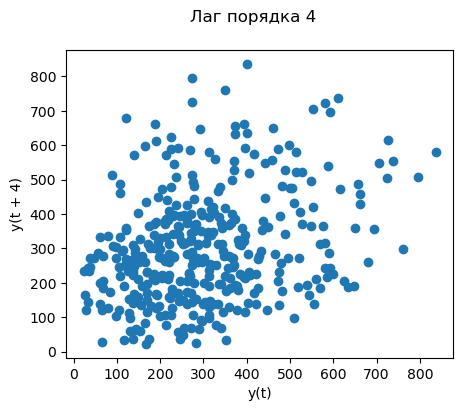

In [15]:
for i in range(1, 5):
    fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(5,4))
    fig.suptitle(f'Лаг порядка {i}')
    pd.plotting.lag_plot(daily_revenue, lag=i, ax=ax)
    pyplot.show()

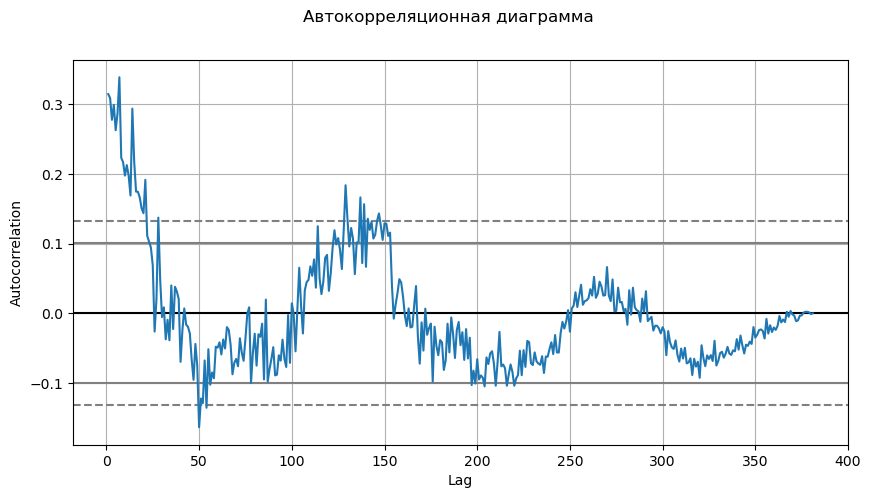

In [16]:
# По оси Y откладывается ковариация 
# https://stats.stackexchange.com/questions/357300/what-does-pandas-autocorrelation-graph-show
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Автокорреляционная диаграмма')
pd.plotting.autocorrelation_plot(daily_revenue, ax=ax)
pyplot.show()

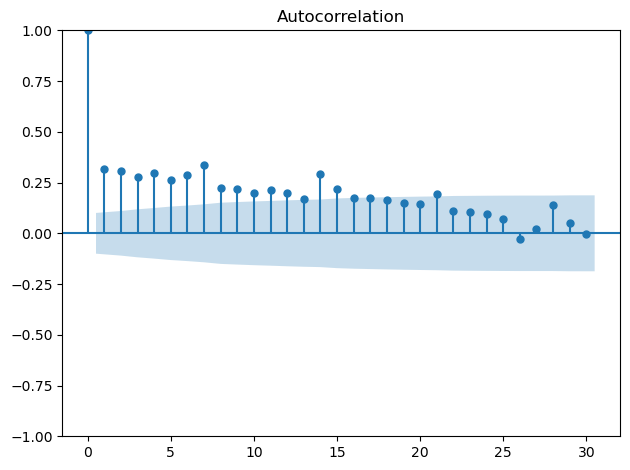

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(daily_revenue, lags=30)
plt.tight_layout()

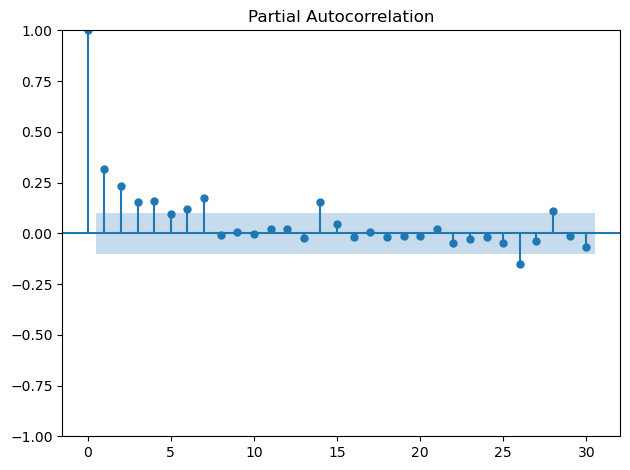

In [18]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(daily_revenue, lags=30)
plt.tight_layout()

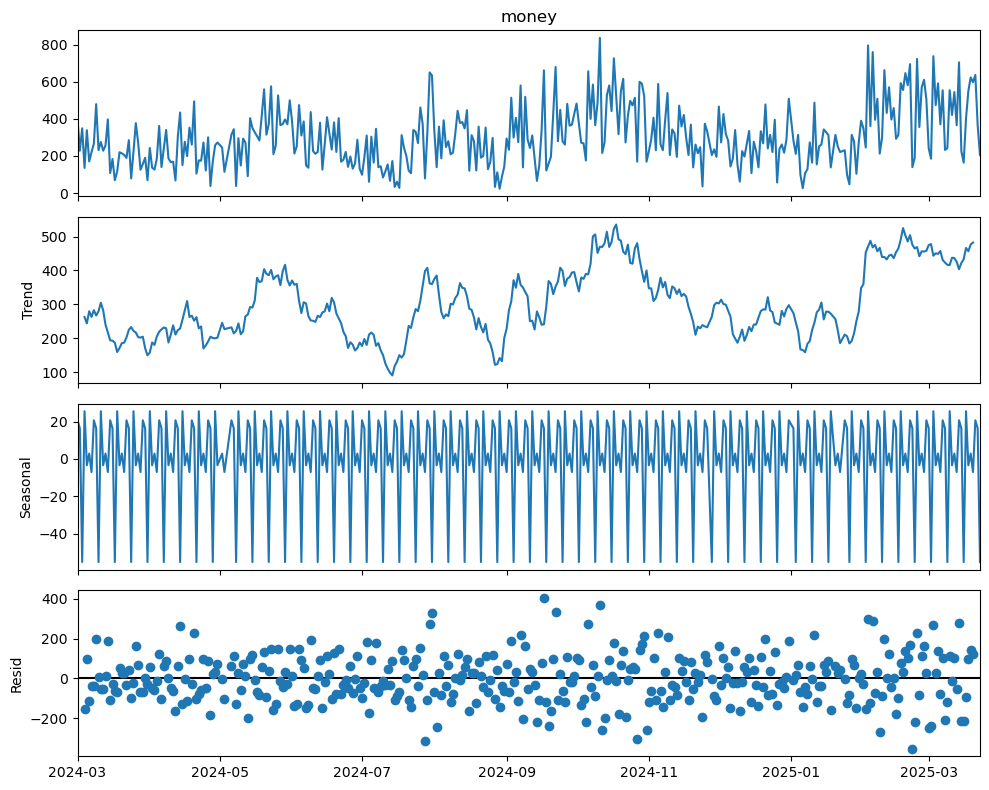

In [19]:
# Превращаем Series в DataFrame
daily_revenue_df = daily_revenue.to_frame(name='money')

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

def plot_decompose(data=daily_revenue_df['money'], model='add', period=7):
    result_add = seasonal_decompose(data, model='add', period=period)
    fig = result_add.plot()
    fig.set_size_inches((10, 8))
    fig.tight_layout()
    plt.show()

plot_decompose(data=daily_revenue_df['money'], model='add', period=7)

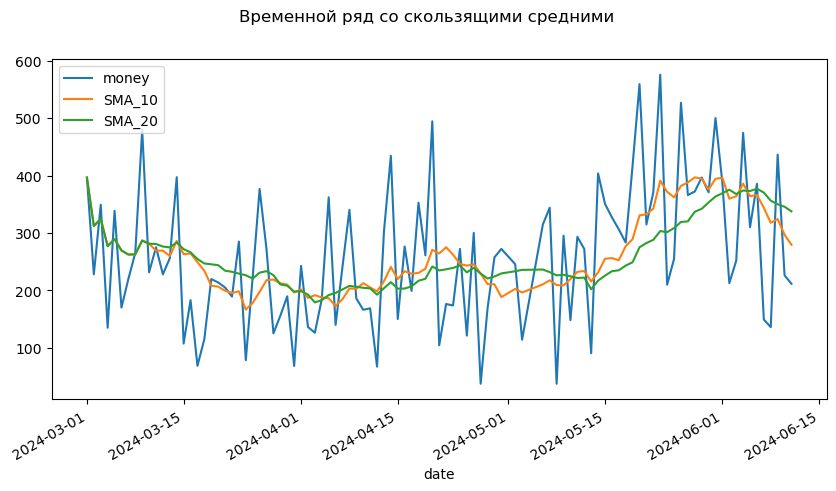

In [30]:
# Скользящая средняя

# Копируем данные
daily_revenue2 = daily_revenue.copy()

# Простое скользящее среднее (SMA)
daily_revenue2 = daily_revenue2.to_frame(name='money')
daily_revenue2['SMA_10'] = daily_revenue2['money'].rolling(10, min_periods=1).mean()
daily_revenue2['SMA_20'] = daily_revenue2['money'].rolling(20, min_periods=1).mean()

# Визуализация
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд со скользящими средними')
daily_revenue2[:100].plot(ax=ax, legend=True)
pyplot.show()

In [31]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [32]:
# Целочисленная метка шкалы времени
xnum = list(range(daily_revenue2.shape[0]))
# Разделение выборки на обучающую и тестовую
Y = daily_revenue2['money'].values
train_size = int(len(Y) * 0.7)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]
history_arima = [x for x in train]
history_es = [x for x in train]

In [34]:
# Параметры модели (p, d, q)
arima_order = (6,1,0)

# Формирование предсказаний
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])
# Обрезаем predictions_arima до длины test
predictions_arima = np.array(predictions_arima[:len(test)])
test_array = np.array(test)

# Вычисляем RMSE
mse = np.mean((test_array - predictions_arima) ** 2)
error_arima = np.sqrt(mse)

print(f"RMSE: {error_arima}")

RMSE: 159.62065421267644


In [35]:
# Формирование предсказаний
predictions_es = list()
for t in range(len(test)):
    model_es = ExponentialSmoothing(history_es)
    model_es_fit = model_es.fit()
    yhat_es = model_es_fit.forecast()[0]
    predictions_es.append(yhat_es)
    history_es.append(test[t])

# Вычисление метрики RMSE (ручками, как для ARIMA)
predictions_es = np.array(predictions_es[:len(test)])
test_array = np.array(test)

mse = np.mean((test_array - predictions_es) ** 2)
error_es = np.sqrt(mse)

print(f"RMSE (Exponential Smoothing): {error_es}")

RMSE (Exponential Smoothing): 157.61117762340157


In [36]:
np.mean(Y), error_arima, error_es

(np.float64(302.9700262467191),
 np.float64(159.62065421267644),
 np.float64(157.61117762340157))

In [37]:
# Записываем предсказания в DataFrame
daily_revenue2['predictions_ARIMA'] = (train_size * [np.nan]) + list(predictions_arima)
daily_revenue2['predictions_HWES'] = (train_size * [np.nan]) + list(predictions_es)

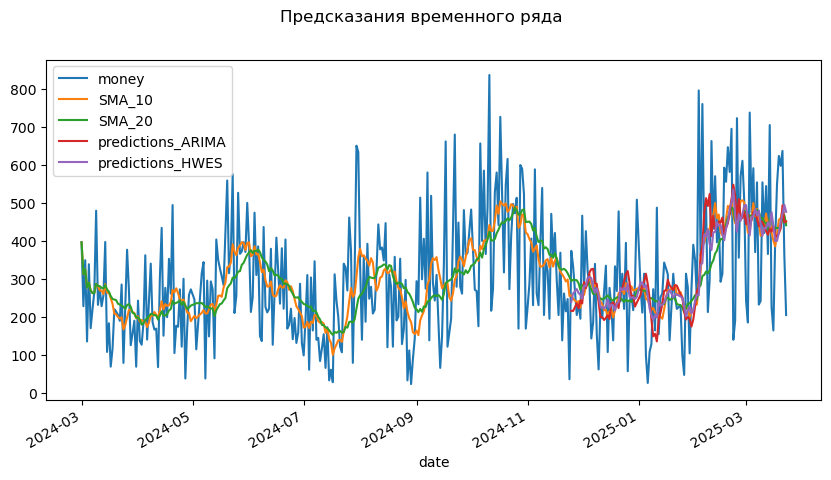

In [38]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда')
daily_revenue2.plot(ax=ax, legend=True)
pyplot.show()

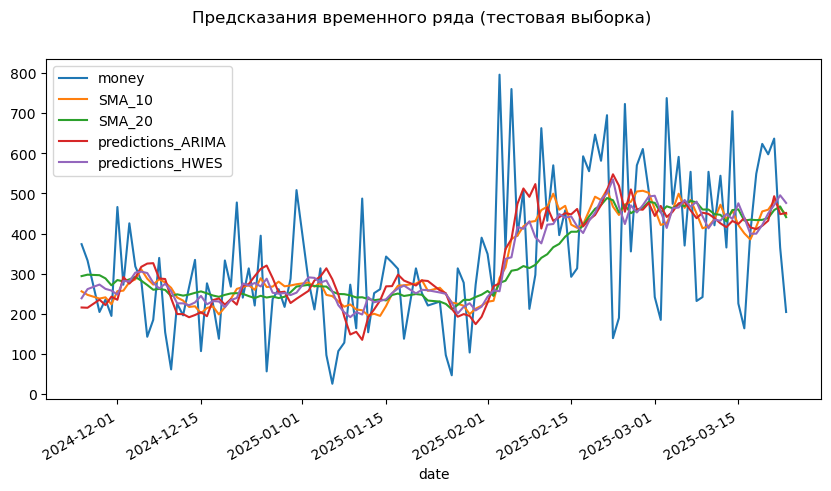

In [39]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
daily_revenue2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

In [40]:
from gplearn.genetic import SymbolicRegressor

In [41]:
function_set = ['add', 'sub', 'mul', 'div', 'sin']
est_gp = SymbolicRegressor(population_size=500, metric='mse',
                               generations=70, stopping_criteria=0.01,
                               init_depth=(4, 10), verbose=1, function_set=function_set,
                               const_range=(-100, 100), random_state=0)

In [42]:
est_gp.fit(np.array(xnum_train).reshape(-1, 1), train.reshape(-1, 1))

C:\Users\masha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0   263.65       7.2107e+55       39          53864.2              N/A      5.39m
   1   153.89      1.84448e+16       39          28784.1              N/A      1.60m
   2    83.52      8.63887e+10       55            21541              N/A      1.19m
   3    50.19      2.83851e+09       63          21155.7              N/A     49.13s
   4    49.82      1.11062e+11       37            21081              N/A      1.01m
   5    57.78      5.79958e+07       84            20827              N/A      1.01m
   6    56.12      3.55021e+06       39          20701.4              N/A     57.89s
   7    54.05      6.82332e+06       84          20620.4              N/A     48.94s
   8    74.73      1.65023e+08       94          20610.3              N/A  

,population_size,500
,generations,70
,tournament_size,20
,stopping_criteria,0.01
,const_range,"(-100, ...)"
,init_depth,"(4, ...)"
,init_method,'half and half'
,function_set,"['add', 'sub', ...]"
,metric,'mse'
,parsimony_coefficient,0.001
,p_crossover,0.9


In [43]:
print(est_gp._program)

sub(sin(add(div(mul(sub(X0, 78.624), div(div(X0, 20.271), 68.555)), div(X0, X0)), sin(sin(-56.150)))), sub(mul(div(add(24.003, 35.637), div(-68.343, sub(X0, 75.483))), sin(sin(-14.028))), sub(add(div(sub(sin(sub(sin(sin(mul(sub(X0, 78.624), div(div(X0, 20.271), 68.555)))), add(sub(mul(sub(X0, 78.624), div(sub(-47.039, X0), 68.555)), sub(sub(sin(add(sub(sub(div(sub(mul(sub(X0, 78.624), div(div(X0, 20.271), 68.555)), sub(-54.473, X0)), div(X0, X0)), div(X0, X0)), div(X0, 20.271)), mul(X0, -15.944))), add(sub(sin(add(sub(div(sub(X0, 78.624), div(X0, X0)), sin(54.531)), mul(X0, -15.944))), sub(sin(div(X0, 20.271)), add(sub(X0, 78.624), sub(sin(mul(sub(X0, 78.624), div(div(X0, 20.271), 68.555))), div(-68.343, sub(X0, 75.483)))))), sub(sin(54.531), div(div(sub(X0, -59.385), div(X0, X0)), add(sub(mul(sub(X0, 78.624), div(sub(-47.039, X0), 68.555)), sub(-54.473, X0)), add(sub(mul(sub(X0, 78.624), div(sub(-47.039, add(56.190, 80.580)), 68.555)), sub(-54.473, X0)), sub(sub(X0, -59.385), div(sub(

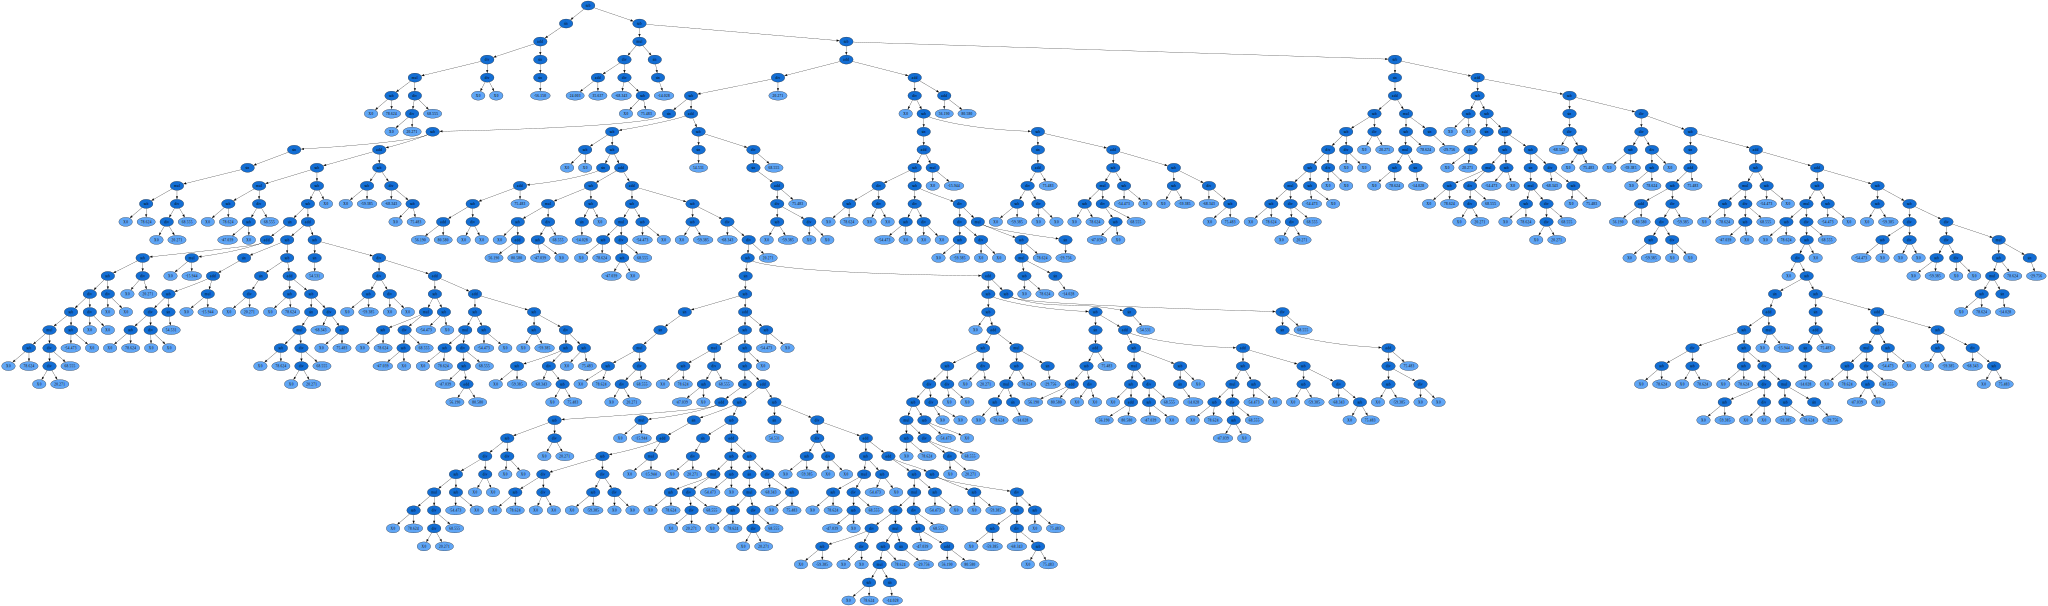

In [44]:
import graphviz
dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph

In [45]:
# Предсказания
y_gp = est_gp.predict(np.array(xnum_test).reshape(-1, 1))
y_gp[:10]

array([374.45938159, 375.95859691, 377.66845956, 379.48934689,
       381.44613013, 383.3363752 , 385.14877821, 386.93072984,
       388.33828597, 389.57398415])

In [47]:
# Записываем предсказания в DataFrame
daily_revenue2['predictions_GPLEARN'] = (train_size * [np.nan]) + list(y_gp)

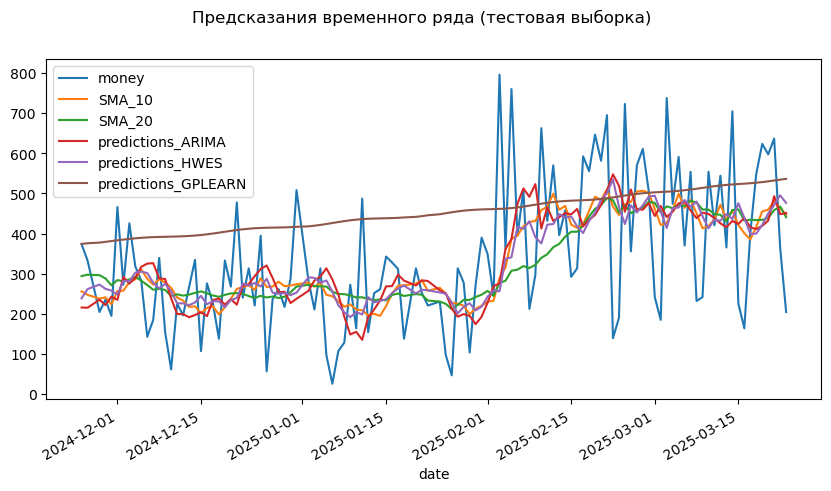

In [48]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
daily_revenue2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

In [49]:
!pip install gmdhpy

In [51]:
!pip install gmdh

     ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
     -- ------------------------------------- 1.0/14.4 MB 9.1 MB/s eta 0:00:02
     -- ------------------------------------- 1.0/14.4 MB 9.1 MB/s eta 0:00:02
     ----- ---------------------------------- 1.8/14.4 MB 2.8 MB/s eta 0:00:05
     -------- ------------------------------- 3.1/14.4 MB 4.2 MB/s eta 0:00:03
     ------------- -------------------------- 5.0/14.4 MB 4.8 MB/s eta 0:00:02
     ----------------- ---------------------- 6.3/14.4 MB 5.4 MB/s eta 0:00:02
     --------------------- ------------------ 7.9/14.4 MB 5.3 MB/s eta 0:00:02
     -------------------------- ------------- 9.4/14.4 MB 5.8 MB/s eta 0:00:01
     -------------------------- ------------- 9.4/14.4 MB 5.8 MB/s eta 0:00:01
     -------------------------- ------------- 9.4/14.4 MB 5.8 MB/s eta 0:00:01
     ----------------------------- ---------- 10.5/14.4 MB 4.5 MB/s eta 0:00:01
     --------------------------------- ------ 12.1/14.4 MB

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [31 lines of output]
  C:\Users\masha\AppData\Local\Temp\pip-build-env-g4jzkroy\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
  !!
  
          ********************************************************************************
          Please consider removing the following classifiers in favor of a SPDX license expression:
  
          License :: OSI Approved :: Apache Software License
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ********************************************************************************
  
  !!
    self._finalize_license_expression()
  running bdist_wheel
  running build
  running build_py
  creating build\lib.win-amd64-cpython-313\gmdh
  copying gmdh\gmdh.py -> build\lib.win-amd64-cpython-313\gmdh
  copying gmdh\version.py -> build\lib.win-amd64-cpython-313\gmdh